## 1. Import Libraries and Implement Helper Functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
# =================
# Helper functions
# =================

def plot_hand_on_axes(
    row: pd.Series,
    ax: plt.Axes,
    feature_cols: list[str],
    title: str | None = None
) -> None:
    """
    Plot one hand gesture (21 landmarks) on the given Matplotlib Axes.
    Expects flattened (x,y,z) features; uses x,y to draw the hand skeleton.
    """

    coords = row[feature_cols].values
    points = coords.reshape(-1, 3)  # (21, 3)
    xs, ys = points[:, 0], points[:, 1]

    # Hand skeleton connections (indices 0–20)
    HAND_CONNECTIONS = [
        (5,9), (9,13), (13,17),                # Palm
        (0, 1), (1, 2), (2, 3), (3, 4),        # Thumb
        (0, 5), (5, 6), (6, 7), (7, 8),        # Index
        (0, 9), (9, 10), (10, 11), (11, 12),   # Middle
        (0, 13), (13, 14), (14, 15), (15, 16), # Ring
        (0, 17), (17, 18), (18, 19), (19, 20)  # Pinky
    ]

    # Plot connections
    for i, j in HAND_CONNECTIONS:
        ax.plot([xs[i], xs[j]], [ys[i], ys[j]], color='steelblue', linewidth=2)

    # Plot keypoints
    ax.scatter(xs, ys, c='red', s=40)

    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])

    if title:
        ax.set_title(title, fontsize=10)


def plot_gesture_grid(
    df: pd.DataFrame,
    n_rows: int = 3,
    n_cols: int = 5,
    random_state: int | None = None
) -> None:
    """
    Visualize a random grid of hand gesture samples.

    This function randomly samples gestures from the input DataFrame and
    displays them in a grid layout using the hand skeleton visualization.
    Each subplot represents one gesture labeled with its class.
    """

    n_samples = n_rows * n_cols
    feature_cols = [col for col in df.columns if col != 'label']

    # Sample data
    sampled_df = df.sample(n=n_samples, random_state=random_state).reset_index(drop=True)

    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
    axes = axes.flatten()

    # Plot each sample
    for i in range(n_samples):
        row = sampled_df.iloc[i]
        lbl = row['label']
        plot_hand_on_axes(row, axes[i], feature_cols, title=str(lbl))

    # Hide unused axes (safe guard)
    for j in range(n_samples, len(axes)):
        axes[j].axis('off')

    fig.suptitle('Sample of Gestures', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def normalize_hand_xy(
    X: pd.DataFrame,
    wrist_col_idx: int = 1,
    mid_finger_tip_col_idx: int = 13,
    eps: float = 1e-8,
) -> pd.DataFrame:
    """Normalize hand landmark X/Y to be translation- and scale-invariant.

    This preprocessing addresses different hand positions and scales:
    - Recenter: subtract the wrist (landmark 0) so it becomes the origin.
    - Rescale: divide all X/Y landmarks by the distance from the wrist to the
      middle-finger tip (landmark 12).
    Z coordinates are not changed.
    """

    Xn = X.copy()

    x_cols = [f'x{i}' for i in range(1, 22)]
    y_cols = [f'y{i}' for i in range(1, 22)]

    wrist_x_col = f'x{wrist_col_idx}'
    wrist_y_col = f'y{wrist_col_idx}'
    mid_x_col = f'x{mid_finger_tip_col_idx}'
    mid_y_col = f'y{mid_finger_tip_col_idx}'

    # Recenter to wrist
    wrist_x = Xn[wrist_x_col].to_numpy()
    wrist_y = Xn[wrist_y_col].to_numpy()
    Xn.loc[:, x_cols] = Xn.loc[:, x_cols].sub(wrist_x, axis=0)
    Xn.loc[:, y_cols] = Xn.loc[:, y_cols].sub(wrist_y, axis=0)

    # Scale using distance to middle finger tip (after recentering)
    mid_x = Xn[mid_x_col].to_numpy()
    mid_y = Xn[mid_y_col].to_numpy()
    scale = np.sqrt(mid_x**2 + mid_y**2)
    scale = np.maximum(scale, eps)

    Xn.loc[:, x_cols] = Xn.loc[:, x_cols].div(scale, axis=0)
    Xn.loc[:, y_cols] = Xn.loc[:, y_cols].div(scale, axis=0)

    return Xn

## 2. Load and Explore Data

In [3]:
# Load dataset
df = pd.read_csv('hand_landmarks_data.csv')

# Basic info
print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (25675, 64)

First 5 rows:


,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

In [5]:
# Statistical summary
df.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,z18,x19,y19,z19,x20,y20,z20,x21,y21,z21
count,25675.000000,25675.000000,2.567500e+04,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,...,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000
mean,201.958632,260.158527,1.272461e-07,202.517395,252.115322,-0.009465,202.862981,240.645966,-0.015946,203.025267,...,-0.024129,201.792374,227.455597,-0.033751,201.811275,227.802576,-0.032208,201.874802,227.807287,-0.028828
std,90.500333,76.533210,2.737932e-07,84.770933,75.384691,0.010376,80.412089,74.721921,0.013973,79.647588,...,0.015658,94.046497,77.231210,0.020453,93.664595,78.441253,0.020877,93.547017,79.963438,0.021136
min,-36.050926,45.722923,-2.029986e-06,7.184681,51.256840,-0.096630,25.114323,45.489950,-0.155846,23.446341,...,-0.201897,0.198635,20.146784,-0.286821,3.278137,32.158108,-0.286470,-4.537216,23.226204,-0.262047
25%,124.110329,205.815950,-5.243216e-08,130.535929,197.999625,-0.015199,136.711035,187.018583,-0.023020,138.905817,...,-0.030728,126.828913,172.720392,-0.042726,126.887403,172.345467,-0.041957,126.356627,172.083794,-0.039220
50%,199.667847,255.181793,1.497277e-07,199.979530,247.113892,-0.008737,200.092758,235.776978,-0.014231,200.482040,...,-0.020969,197.579865,221.781479,-0.029942,197.591736,222.381149,-0.028510,197.453270,222.485229,-0.025269
75%,266.428482,304.991663,2.989988e-07,261.147457,296.850769,-0.002783,255.876354,284.925993,-0.007134,254.622768,...,-0.013661,268.103920,273.190765,-0.019987,267.745743,274.196884,-0.017971,267.324657,275.805222,-0.014294
max,633.556020,781.674469,1.876254e-06,606.232386,751.869416,0.076365,598.541348,719.365010,0.094131,607.999801,...,0.031774,632.923029,779.419948,0.078105,638.134761,760.854103,0.104580,641.788521,760.554894,0.118668


In [6]:
# Check for missing values
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

x1       0
y1       0
z1       0
x2       0
y2       0
        ..
z20      0
x21      0
y21      0
z21      0
label    0
Length: 64, dtype: int64

Total missing: 0


In [7]:
# Check if there are duplicates in the data
df[df.duplicated()]

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label


In [8]:
# Class distribution
label_counts = df['label'].value_counts()
print('Class Distribution:')
print(label_counts)
print(f'\nNumber of unique classes: {df["label"].nunique()}')

Class Distribution:
label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64

Number of unique classes: 18


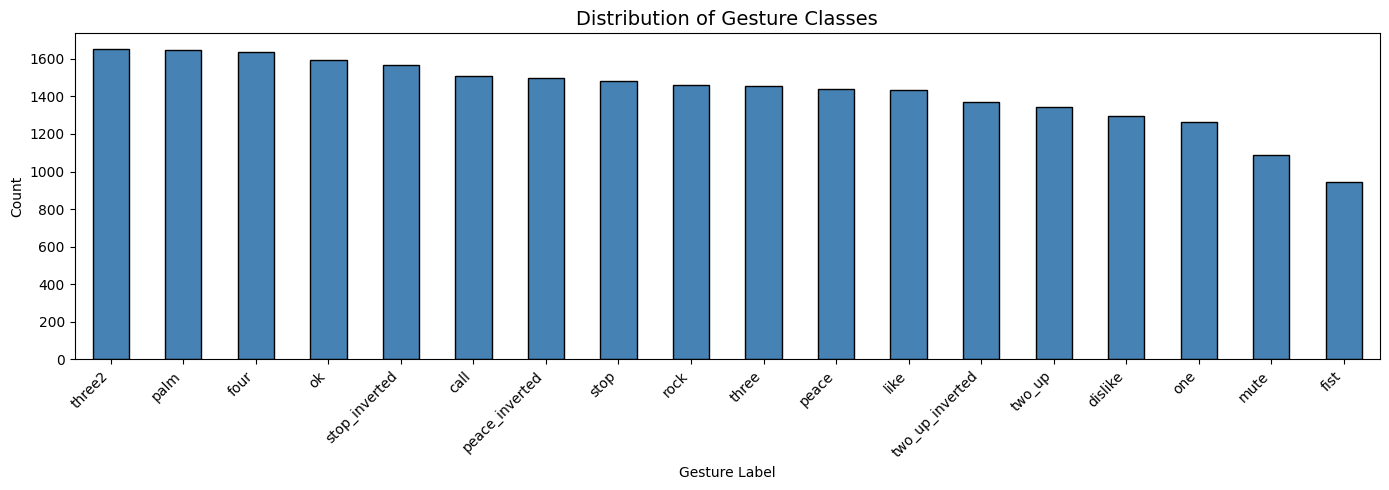

In [9]:
# Class distribution bar plot
plt.figure(figsize=(14, 5))
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Gesture Classes', fontsize=14)
plt.xlabel('Gesture Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Data Visualization

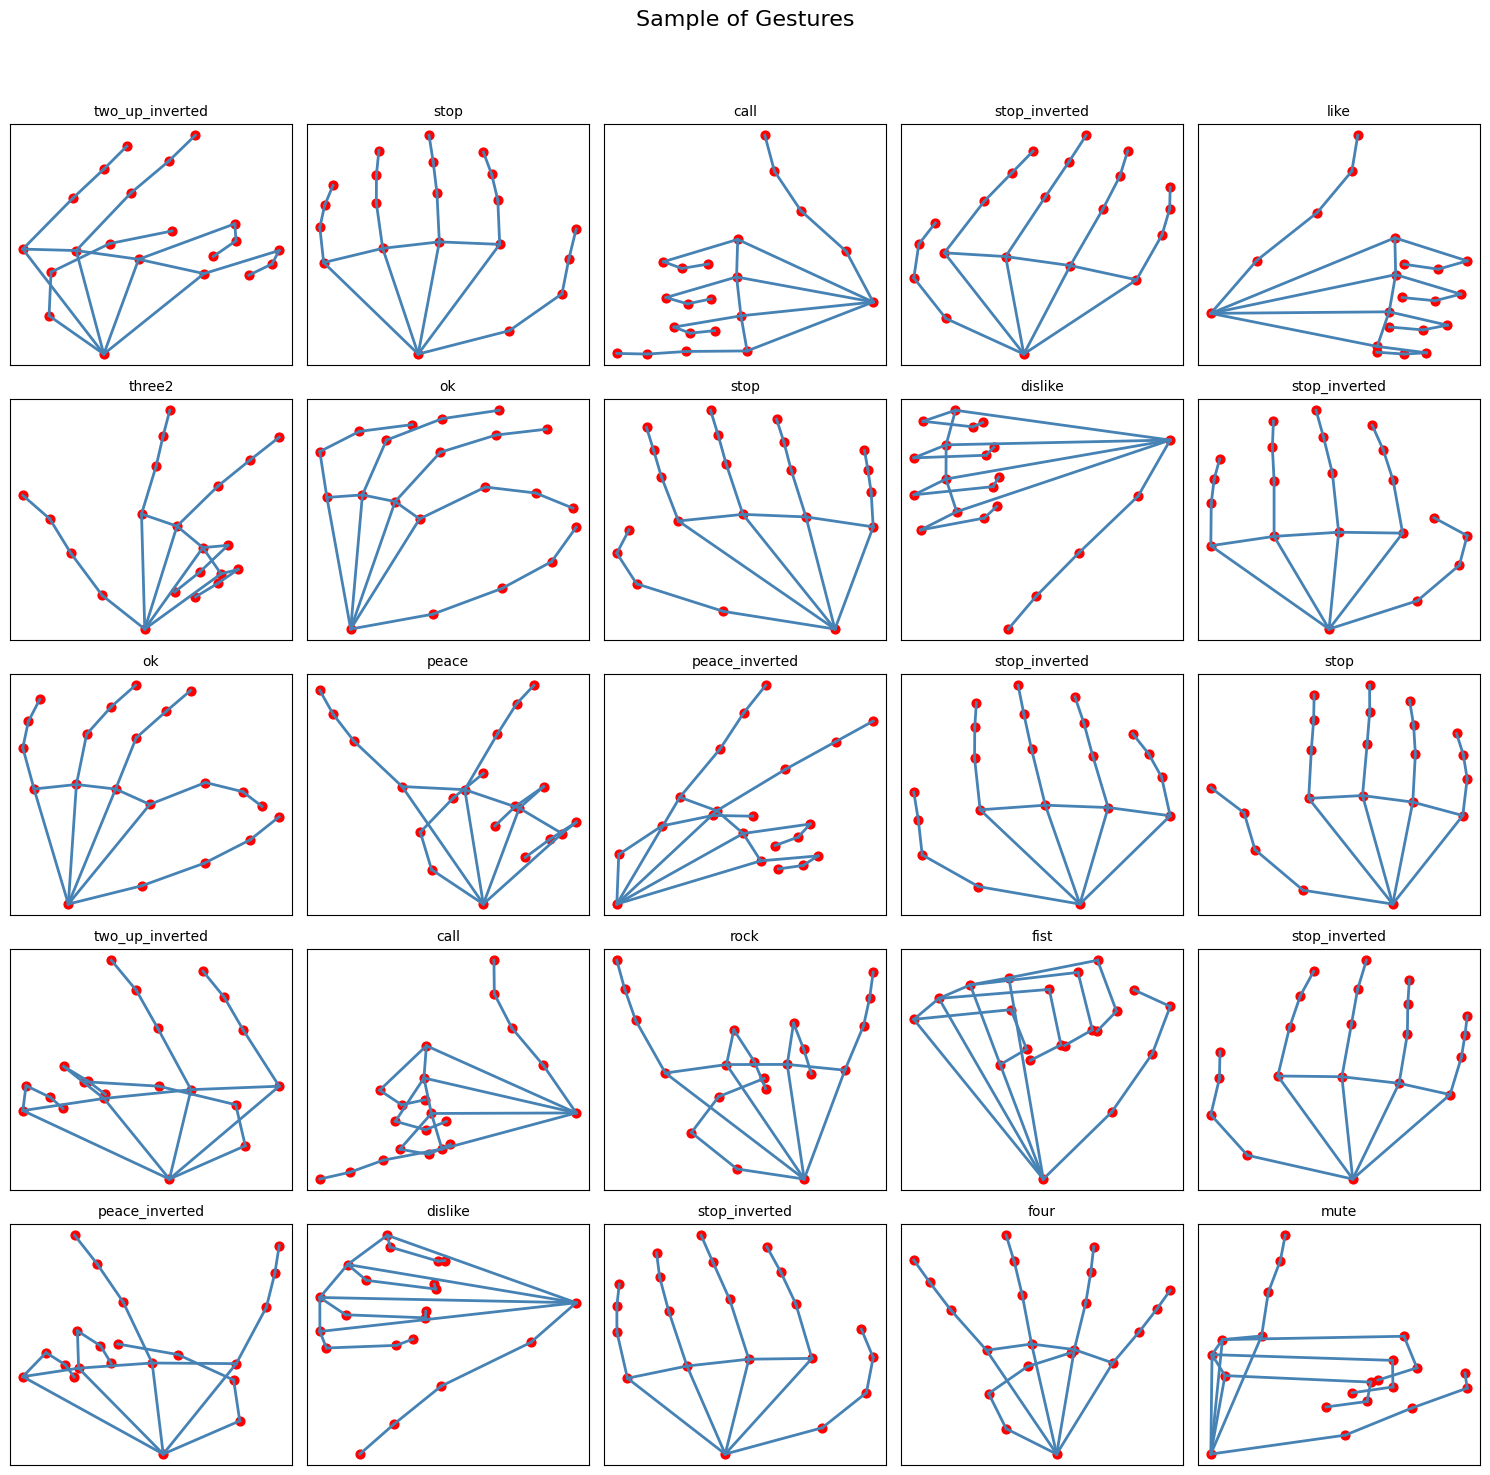

In [10]:
plot_gesture_grid(df=df,n_rows=5,n_cols=5)

## 4. Data Preprocessing

In this section, we clean, normalize, and split the data into training and test sets.

In [11]:
# Features and target
X = df.drop(columns=['label'])
y = df['label']

# Apply the required normalization (X/Y only)
X_normalized = normalize_hand_xy(X)

In [12]:
# Initialize Encoder
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Print the mapping
for i, label in enumerate(encoder.classes_):
    print(f"{i}: {label}")

0: call
1: dislike
2: fist
3: four
4: like
5: mute
6: ok
7: one
8: palm
9: peace
10: peace_inverted
11: rock
12: stop
13: stop_inverted
14: three
15: three2
16: two_up
17: two_up_inverted


In [13]:
# Split data to train and test_validate
X_train, X_test_validate, y_train, y_test_validate = train_test_split(
    X_normalized, 
    y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print('Train shape:', X_train.shape, y_train.shape)
print('Test_Validation shape:', X_test_validate.shape, y_test_validate.shape)

Train shape: (20540, 63) (20540,)
Test_Validation shape: (5135, 63) (5135,)


In [14]:
# Split test_validate to validation and test
X_validation, X_test, y_validation, y_test = train_test_split(
    X_test_validate, 
    y_test_validate, 
    test_size=0.5, 
    random_state=42, 
    stratify=y_test_validate
)

print('Validation shape:', X_validation.shape, y_validation.shape)
print('Test shape:', X_test.shape, y_test.shape)

Validation shape: (2567, 63) (2567,)
Test shape: (2568, 63) (2568,)
